In [11]:
import os
import geopandas as gpd
import requests
import pandas as pd
import matplotlib.pyplot as plt

Fetching data for: Demografi...
-> Success. Found 75 features.
Fetching data for: Bahaya Longsor...
-> Success. Found 1436 features.
Fetching data for: Bahaya Tsunami...
-> Success. Found 125 features.
Fetching data for: Bahaya Banjir...
-> Success. Found 2411 features.


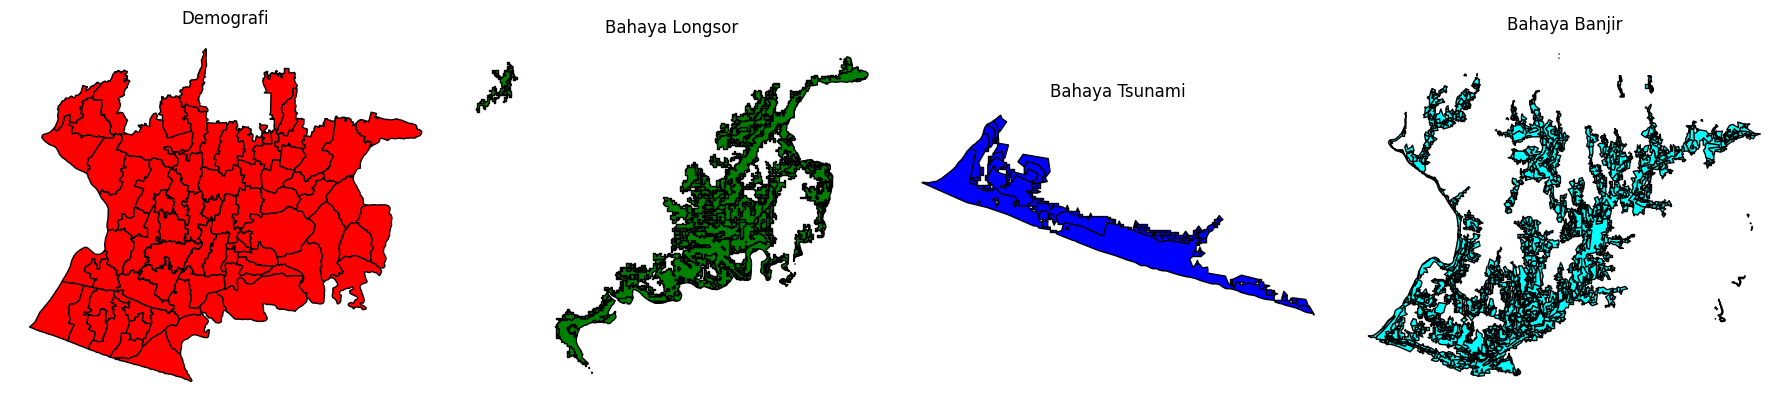

In [ ]:
urls = {
    "Demografi": "https://geoserver.mapid.io/layers_new/get_layer?api_key=8ab8b746ee23449e804ad176ee92a5cb&layer_id=68af18c7b2fcc5561a33afdb&project_id=68af10b0ef2411f2c7b6e63e&limit=10000",
    "Bahaya Longsor": "https://geoserver.mapid.io/layers_new/get_layer?api_key=8ab8b746ee23449e804ad176ee92a5cb&layer_id=68af17f2b2fcc5561a33a064&project_id=68af10b0ef2411f2c7b6e63e&limit=10000",
    "Bahaya Tsunami": "https://geoserver.mapid.io/layers_new/get_layer?api_key=8ab8b746ee23449e804ad176ee92a5cb&layer_id=68af17f2b2fcc5561a33a066&project_id=68af10b0ef2411f2c7b6e63e&limit=10000" ,
    "Bahaya Banjir" : "https://geoserver.mapid.io/layers_new/get_layer?api_key=8ab8b746ee23449e804ad176ee92a5cb&layer_id=68af17f0b2fcc5561a338d7a&project_id=68af10b0ef2411f2c7b6e63e&limit=10000"
}

def get_data(url, layer_name):
    print(f"Fetching data for: {layer_name}...")
    response = requests.get(url)
    if response.status_code == 200:
        geojson_data = response.json()
        gdf = gpd.GeoDataFrame.from_features(geojson_data['features'])
        
        gdf = gdf.set_crs("EPSG:4326")
        
        print(f"-> Success. Found {len(gdf)} features.")

        if layer_name == "Demografi":
            class_labels = ['RENDAH', 'SEDANG', 'TINGGI']
            gdf['KELAS_DEMOGRAFI'] = pd.qcut(
                gdf['JUMLAH PENDUDUK'],
                q=3,
                labels=class_labels,
                duplicates='drop'
            )
            gdf["SKOR_DEMOGRAFI"] = gdf['KELAS_DEMOGRAFI'].map({'RENDAH': 1, 'SEDANG': 2, 'TINGGI': 3})
            gdf["SKOR_DEMOGRAFI"] = gdf["SKOR_DEMOGRAFI"].astype(int)

        else:
            hazard_score_map = {'SANGAT RENDAH': 1, 'CUKUP RENDAH': 2, 'SEDANG': 3, 'CUKUP TINGGI': 4, 'SANGAT TINGGI': 5}
            if 'Kelas' in gdf.columns:
                class_values = gdf['Kelas'].str.upper()
                if layer_name == "Bahaya Longsor":
                    gdf["SKOR_LONGSOR"] = class_values.map(hazard_score_map).fillna(0).astype(int)
                elif layer_name == "Bahaya Tsunami":
                    gdf["SKOR_TSUNAMI"] = class_values.map(hazard_score_map).fillna(0).astype(int)
                elif layer_name == "Bahaya Banjir":
                    gdf["SKOR_BANJIR"] = class_values.map(hazard_score_map).fillna(0).astype(int)
            else:
                print(f"Warning: Column 'Kelas' not found in {layer_name}. Skipping scoring.")

        return gdf
    print(f"-> Failed to fetch data for {layer_name}.")
    return gpd.GeoDataFrame()

gdf_demografi = get_data(urls["Demografi"], "Demografi")
gdf_longsor = get_data(urls["Bahaya Longsor"], "Bahaya Longsor")
gdf_tsunami = get_data(urls["Bahaya Tsunami"], "Bahaya Tsunami")
gdf_banjir = get_data(urls["Bahaya Banjir"], "Bahaya Banjir")

def visualize_data (gdfs):
    fig, axes = plt.subplots(1, len(gdfs), figsize=(18, 6))
    color_map = ['red', 'green', 'blue', 'cyan']
    for ax, (name, gdf), color in zip(axes, gdfs.items(), color_map):
        gdf.plot(ax=ax, color=color, edgecolor='black')
        ax.set_title(name)
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()

visualize_data({
    "Demografi": gdf_demografi,
    "Bahaya Longsor": gdf_longsor,
    "Bahaya Tsunami": gdf_tsunami,
    "Bahaya Banjir": gdf_banjir
})

In [ ]:
print("\n--- Starting Multi-Hazard Risk Modeling ---")
print("Step 1: Unifying hazard layers...")

target_crs = "EPSG:4326"
gdf_demografi = gdf_demografi.to_crs(target_crs)
gdf_longsor = gdf_longsor.to_crs(target_crs)
gdf_tsunami = gdf_tsunami.to_crs(target_crs)
gdf_banjir = gdf_banjir.to_crs(target_crs)

unified_hazards = gdf_longsor.copy()

if not gdf_tsunami.empty:
    unified_hazards = gpd.overlay(unified_hazards, gdf_tsunami, how='union', keep_geom_type=True)
if not gdf_banjir.empty:
    unified_hazards = gpd.overlay(unified_hazards, gdf_banjir, how='union', keep_geom_type=True)
print("-> Union of hazard layers complete.")

print("Step 2: Calculating total hazard score...")

hazard_score_columns = ['SKOR_LONGSOR', 'SKOR_TSUNAMI', 'SKOR_BANJIR']
for col in hazard_score_columns:
    if col in unified_hazards.columns:
        unified_hazards[col] = unified_hazards[col].fillna(0)

unified_hazards['SKOR_GABUNGAN_BAHAYA'] = unified_hazards[hazard_score_columns].sum(axis=1)
print("-> Total hazard score calculated.")

print("Step 3: Intersecting hazards with demographic data...")
risk_analysis_gdf = gpd.overlay(unified_hazards, gdf_demografi, how='intersection', keep_geom_type=True)
print("-> Intersection with demographics complete.")

if not risk_analysis_gdf.empty:
    risk_analysis_gdf['geometry'] = risk_analysis_gdf.geometry.buffer(0)
    print("-> Geometries validated.")

print("Step 4: Calculating final risk index...")

risk_analysis_gdf['SKOR_DEMOGRAFI'] = risk_analysis_gdf['SKOR_DEMOGRAFI'].fillna(0)
risk_analysis_gdf['INDEKS_RISIKO_FINAL'] = risk_analysis_gdf['SKOR_GABUNGAN_BAHAYA'] * risk_analysis_gdf['SKOR_DEMOGRAFI']
print("-> Final risk index calculated.")

print("Step 5: Classifying final risk scores using Quantiles...")

labels = ['RISIKO RENDAH', 'RISIKO SEDANG', 'RISIKO TINGGI']

risk_analysis_gdf['TINGKAT_RISIKO'] = pd.qcut(
    risk_analysis_gdf['INDEKS_RISIKO_FINAL'],
    q=3,                        
    labels=labels,              
    duplicates='drop'           
)

print("\n--- Final Multi-Hazard Risk Analysis Result ---")
print(risk_analysis_gdf[['SKOR_GABUNGAN_BAHAYA', 'SKOR_DEMOGRAFI', 'INDEKS_RISIKO_FINAL', 'TINGKAT_RISIKO']].head(10000))


--- Starting Multi-Hazard Risk Modeling ---
Step 1: Unifying hazard layers...
-> Union of hazard layers complete.
Step 2: Calculating total hazard score...
-> Total hazard score calculated.
Step 3: Intersecting hazards with demographic data...
-> Intersection with demographics complete.
-> Geometries validated.
Step 4: Calculating final risk index...
-> Final risk index calculated.
Step 5: Classifying final risk scores using Quantiles...

--- Final Multi-Hazard Risk Analysis Result ---
      SKOR_GABUNGAN_BAHAYA  SKOR_DEMOGRAFI  INDEKS_RISIKO_FINAL TINGKAT_RISIKO
0                      5.0               3                 15.0  RISIKO TINGGI
1                      5.0               3                 15.0  RISIKO TINGGI
2                      4.0               3                 12.0  RISIKO TINGGI
3                      7.0               3                 21.0  RISIKO TINGGI
4                      6.0               3                 18.0  RISIKO TINGGI
...                    ...        

In [30]:
print("\n--- Starting the file saving process ---")

output_dir = "C:\ProjectM2\MAPID\WEBGIS_ACADEMY\Output_MultiHazard_Bantul"

os.makedirs(output_dir, exist_ok=True)
print(f"Output directory is set to: {output_dir}")

print("Saving initial data layers...")
if not gdf_demografi.empty:
    gdf_demografi.to_file(os.path.join(output_dir, "skor_demografi.geojson"), driver='GeoJSON')
if not gdf_longsor.empty:
    gdf_longsor.to_file(os.path.join(output_dir, "skor_bahaya_longsor.geojson"), driver='GeoJSON')
if not gdf_tsunami.empty:
    gdf_tsunami.to_file(os.path.join(output_dir, "skor_bahaya_tsunami.geojson"), driver='GeoJSON')
if not gdf_banjir.empty:
    gdf_banjir.to_file(os.path.join(output_dir, "skor_bahaya_banjir.geojson"), driver='GeoJSON')
print("-> Initial layers saved.")

final_polygons_gdf = risk_analysis_gdf[risk_analysis_gdf.geometry.type.isin(['Polygon', 'MultiPolygon'])]

print("Saving final analysis result...")
final_polygons_gdf.to_file(os.path.join(output_dir, "Analisis_Risiko_Final.geojson"), driver='GeoJSON')
print("-> Final analysis saved.")

print("\nAll GeoJSON files have been successfully saved.")

<>:3: SyntaxWarning: invalid escape sequence '\P'
<>:3: SyntaxWarning: invalid escape sequence '\P'
C:\Users\drsdi\AppData\Local\Temp\ipykernel_23448\3458221869.py:3: SyntaxWarning: invalid escape sequence '\P'
  output_dir = "C:\ProjectM2\MAPID\WEBGIS_ACADEMY\Output_MultiHazard_Bantul"



--- Starting the file saving process ---
Output directory is set to: C:\ProjectM2\MAPID\WEBGIS_ACADEMY\Output_MultiHazard_Bantul
Saving initial data layers...
-> Initial layers saved.
Saving final analysis result...
-> Final analysis saved.

All GeoJSON files have been successfully saved.


Penjelasan Script Singkat:

Tujuan utama dari analisis & pemodelan spasial kali ini adalah untuk melakukan penilaian risiko multi-bencana untuk Daerah Kabupaten Bantul. Daripada melihat ancaman tunggal secara terpisah, analisis ini menggabungkan berbagai jenis bahaya—tanah longsor, tsunami, dan banjir dengan data kependudukan untuk mengidentifikasi wilayah mana yang secara keseluruhan paling berbahaya. Prinsip utamanya adalah bahwa risiko sejati merupakan kombinasi dari bahaya fisik suatu tempat (hazard) dan jumlah orang yang akan terdampak (vulnerability). Alhasil, script ini mengotomatiskan keseluruhan proses, mulai dari mengambil data mentah hingga menghasilkan peta risiko akhir yang terklasifikasi.

Pertama-tama, script menyiapkan data yang diperlukan dengan mengambil empat layer yang berbeda dari API GEOMAPID: tiga peta bahaya dan satu peta demografi. Fungsi get_data sangat krusial karena ia menstandardisasi kumpulan data yang bervariasi ini ke dalam format yang dapat digunakan. Untuk layer bahaya, ia menerjemahkan kelas deskriptif seperti 'SANGAT TINGGI' menjadi skor numerik (misalnya, 5). Untuk layer demografi, yang berisi angka populasi mentah, ia menggunakan metode statistik (pd.qcut) untuk mengklasifikasikan setiap area ke dalam kelompok populasi 'RENDAH', 'SEDANG', atau 'TINGGI', yang kemudian juga diubah menjadi skor numerik. Proses skoring ini sangat penting karena ia mengubah data kualitatif menjadi data kuantitatif yang dapat digunakan dalam perhitungan matematis.

Fase berikutnya yang paling krusial adalah pemodelan spasial itu sendiri. Untuk menciptakan gambaran komprehensif dari semua potensi bahaya, ketiga layer bahaya individu digabungkan menjadi satu "peta bahaya terpadu" menggunakan operasi union. Ini menciptakan peta tumpang tindih yang kompleks di mana setiap area kecil berisi informasi gabungan dari semua bahaya. Setelah menyatukan semua bahaya, script melakukan intersection dengan layer demografi. Langkah ini seperti menumpuk peta populasi di atas peta bahaya terpadu untuk mengetahui secara pasti populasi mana yang tinggal di dalam zona bahaya mana, dengan melampirkan skor kerentanan demografis ke setiap area spesifik.

Terakhir, script menghitung risiko aktual dan menyajikan hasilnya. Script menghitung INDEKS_RISIKO_FINAL akhir untuk setiap poligon dengan mengalikan skor total bahaya dengan skor kerentanan demografisnya, mengikuti formula standar: Risiko = Bahaya x Kerentanan (Sebenarnya kurang parameter kapasitas sebagai pembagi keduanya, cuma kali ini parameter tersebut akan dilengkahi). Indeks ini secara efektif menyoroti area di mana tingkat bahaya tinggi dan populasi tinggi berada di lokasi yang sama. Karena indeks numerik mentah bisa sulit untuk diinterpretasikan, script kemudian menggunakan pd.cut untuk mengklasifikasikan skor ini ke dalam kategori yang sederhana dan intuitif: 'RISIKO RENDAH', 'RISIKO SEDANG', dan 'RISIKO TINGGI'. Sebagai langkah terakhir, script menyimpan semua layer skor perantara dan peta analisis risiko akhir sebagai file GeoJSON, menciptakan catatan analisis yang permanen dan dapat dibagikan.
